# 切口 A · Step 1 — 假死用户画像与召回建议

**目标**:基于 04 notebook 的三层划分,在每层定假死阈值,抓出假死用户名单,
做 Day 1-2 行为画像对比(假死 vs 活跃),给出召回建议。

**前置约定**(来自 04 notebook):
- C2 cohort: 864,829 用户
- 三层(基于 Day 1-2 总行为数):低活跃 ≤8 / 中活跃 9-25 / 高活跃 >25
- 观察期:Day 3-7(5 天,排除双 12)

**假死定义**(用稍宽松的"接近假死",保留足够样本量做画像):
- 低活跃假死:D3-7 日均 ≤ 1(几乎不来)
- 中活跃假死:D3-7 日均 ≤ 2
- 高活跃假死:D3-7 日均 ≤ 3

**重要 caveat**:由于回归均值现象(详见 06 notebook),传统假死分析在 9 天窗口下
有局限。本 notebook 提供"小样本但定义清晰的假死画像",作为切口 A 的基础结果。

**本 notebook 不做**:跨层迁移分析、回归均值方法论讨论 → 都在 06 notebook。

## 0. 环境与数据

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

PARQUET_PATH = Path('../data/processed/DWD/user_behavior_clean.parquet').resolve()
con = duckdb.connect()
con.execute(f"""
CREATE OR REPLACE VIEW ub AS
SELECT user_id, item_id, category_id, behavior_type, timestamp,
       CAST(to_timestamp(timestamp) AS DATE)      AS event_date,
       EXTRACT(HOUR FROM to_timestamp(timestamp)) AS hour
FROM '{PARQUET_PATH.as_posix()}'
""")
print('视图 ub 已建立')

视图 ub 已建立


---

## 1. 构建用户级特征表(只用 Day 1-2 数据)

每个 cohort 用户提取 Day 1-2 的 **8 个特征**(以及 Day 3-7 用于标记假死):

| 特征 | 含义 |
|---|---|
| d12_actions | Day 1-2 总行为数 |
| d12_pv / cart / fav / buy | 四类行为各自的次数 |
| d12_unique_items | Day 1-2 浏览的独立商品数 |
| d12_unique_categories | Day 1-2 浏览的独立类目数 |
| d12_has_cart / has_fav / has_buy | 是否有过加购 / 收藏 / 购买(0/1) |
| d37_actions / d37_per_day | Day 3-7 总数和日均,**仅用于标记假死,不当特征** |

In [2]:
# 一口气拉出所有特征
cohort_df = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
),
d12_features AS (
    SELECT
        user_id,
        COUNT(*)                                                AS d12_actions,
        SUM(CASE WHEN behavior_type='pv'   THEN 1 ELSE 0 END)   AS d12_pv,
        SUM(CASE WHEN behavior_type='cart' THEN 1 ELSE 0 END)   AS d12_cart,
        SUM(CASE WHEN behavior_type='fav'  THEN 1 ELSE 0 END)   AS d12_fav,
        SUM(CASE WHEN behavior_type='buy'  THEN 1 ELSE 0 END)   AS d12_buy,
        COUNT(DISTINCT item_id)                                 AS d12_unique_items,
        COUNT(DISTINCT category_id)                             AS d12_unique_categories
    FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
    GROUP BY user_id
),
d37_summary AS (
    SELECT user_id, COUNT(*) AS d37_actions
    FROM ub
    WHERE event_date BETWEEN DATE '2017-11-27' AND DATE '2017-12-01'
    GROUP BY user_id
)
SELECT
    c.user_id,
    f.d12_actions, f.d12_pv, f.d12_cart, f.d12_fav, f.d12_buy,
    f.d12_unique_items, f.d12_unique_categories,
    COALESCE(d.d37_actions, 0)         AS d37_actions,
    COALESCE(d.d37_actions, 0) / 5.0   AS d37_per_day
FROM cohort c
JOIN d12_features f ON c.user_id = f.user_id
LEFT JOIN d37_summary d ON c.user_id = d.user_id
""").df()

# 衍生列
cohort_df['d12_has_cart'] = (cohort_df['d12_cart'] > 0).astype(int)
cohort_df['d12_has_fav']  = (cohort_df['d12_fav']  > 0).astype(int)
cohort_df['d12_has_buy']  = (cohort_df['d12_buy']  > 0).astype(int)

# 分层
cohort_df['tier'] = pd.cut(cohort_df['d12_actions'],
                           bins=[0, 8, 25, float('inf')],
                           labels=['低活跃', '中活跃', '高活跃'])

# 标记假死(per-tier 阈值)
TIER_DEAD_THRESHOLD = {'低活跃': 1.0, '中活跃': 2.0, '高活跃': 3.0}

def is_dead(row):
    return row['d37_per_day'] <= TIER_DEAD_THRESHOLD[row['tier']]

cohort_df['is_dead'] = cohort_df.apply(is_dead, axis=1)

print(f'cohort 用户数: {len(cohort_df):,}')
print()
print('前 3 行预览:')
print(cohort_df.head(3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

cohort 用户数: 864,829

前 3 行预览:
   user_id  d12_actions  d12_pv  d12_cart  d12_fav  d12_buy  d12_unique_items  \
0   178880            7     5.0       1.0      0.0      1.0                 3   
1   179008           34    34.0       0.0      0.0      0.0                26   
2    17920           16    16.0       0.0      0.0      0.0                16   

   d12_unique_categories  d37_actions  d37_per_day  d12_has_cart  d12_has_fav  \
0                      2           38          7.6             1            0   
1                     20           98         19.6             0            0   
2                     10           63         12.6             0            0   

   d12_has_buy tier  is_dead  
0            1  低活跃    False  
1            0  高活跃    False  
2            0  中活跃    False  


---

## 2. 每层假死率与样本量

In [3]:
# 每层假死统计
summary = cohort_df.groupby('tier', observed=True).agg(
    total_users=('user_id', 'count'),
    dead_users =('is_dead', 'sum'),
).reset_index()
summary['alive_users']   = summary['total_users'] - summary['dead_users']
summary['dead_rate_pct'] = (summary['dead_users'] / summary['total_users'] * 100).round(2)
summary['threshold']     = summary['tier'].map(TIER_DEAD_THRESHOLD)

print('每层假死统计:')
print(summary[['tier', 'total_users', 'alive_users', 'dead_users', 'dead_rate_pct', 'threshold']])
print()
print(f'三层假死合计: {summary["dead_users"].sum():,} 人 '
      f'(占 cohort {summary["dead_users"].sum() / len(cohort_df) * 100:.2f}%)')

每层假死统计:
  tier  total_users  alive_users  dead_users  dead_rate_pct threshold
0  低活跃       305242       256194       49048          16.07       1.0
1  中活跃       280316       239388       40928          14.60       2.0
2  高活跃       279271       253690       25581           9.16       3.0

三层假死合计: 115,557 人 (占 cohort 13.36%)


**读这张表**:
- `dead_rate_pct` 是每层各自的假死率
- 如果某层假死率 < 5%,**那层的统计结论可能不太稳健**,后面看到结论时要注意 caveat
- 三层假死合计就是后续画像分析的总样本

---

## 3. 假死 vs 活跃画像对比(Day 1-2 特征)

针对每个 tier,比较假死和活跃用户在 Day 1-2 的行为特征差异。

In [4]:
# 比较函数:对每个 tier 内的假死 / 活跃,各特征算均值、中位数、t检验
features_to_compare = [
    'd12_actions', 'd12_pv', 'd12_cart', 'd12_fav', 'd12_buy',
    'd12_unique_items', 'd12_unique_categories',
    'd12_has_cart', 'd12_has_fav', 'd12_has_buy',
]

def compare_features_in_tier(df_tier, tier_name):
    dead   = df_tier[df_tier['is_dead']]
    alive  = df_tier[~df_tier['is_dead']]
    rows = []
    for feat in features_to_compare:
        dead_mean  = dead[feat].mean()
        alive_mean = alive[feat].mean()
        diff_pct   = (dead_mean - alive_mean) / alive_mean * 100 if alive_mean != 0 else np.nan
        # 用 Mann-Whitney U 检验(非正态分布更稳健)
        try:
            stat, p = stats.mannwhitneyu(dead[feat], alive[feat], alternative='two-sided')
        except ValueError:
            p = np.nan
        rows.append({
            'feature':       feat,
            'alive_mean':    round(alive_mean, 3),
            'dead_mean':     round(dead_mean, 3),
            'diff_pct':      round(diff_pct, 1) if not np.isnan(diff_pct) else np.nan,
            'p_value':       f'{p:.2e}' if not np.isnan(p) else 'N/A',
            'significant':   '✓' if (not np.isnan(p) and p < 0.001) else '',
        })
    return pd.DataFrame(rows)

for tier_name in ['低活跃', '中活跃', '高活跃']:
    df_tier = cohort_df[cohort_df['tier'] == tier_name]
    print(f'\n========== {tier_name}(假死 {df_tier["is_dead"].sum():,} vs 活跃 {(~df_tier["is_dead"]).sum():,}) ==========')
    print(compare_features_in_tier(df_tier, tier_name).to_string(index=False))


========== 低活跃(假死 49,048 vs 活跃 256,194) ==========
              feature  alive_mean  dead_mean  diff_pct  p_value significant
          d12_actions       3.976      3.385     -14.9 0.00e+00           ✓
               d12_pv       3.442      2.869     -16.7 0.00e+00           ✓
             d12_cart       0.268      0.241      -9.9 2.96e-23           ✓
              d12_fav       0.111      0.087     -21.0 4.90e-40           ✓
              d12_buy       0.155      0.188      21.1 1.13e-53           ✓
     d12_unique_items       3.724      3.158     -15.2 0.00e+00           ✓
d12_unique_categories       2.645      2.230     -15.7 0.00e+00           ✓
         d12_has_cart       0.191      0.172      -9.9 8.82e-23           ✓
          d12_has_fav       0.079      0.062     -22.0 4.50e-40           ✓
          d12_has_buy       0.129      0.155      19.8 7.90e-53           ✓

========== 中活跃(假死 40,928 vs 活跃 239,388) ==========
              feature  alive_mean  dead_mean  diff_pct  p_va

**怎么读这三张表**:
- `alive_mean / dead_mean`:同层内活跃用户 vs 假死用户在该特征上的均值
- `diff_pct`:假死比活跃**少了**(或多了)百分之几。负数 = 假死方少
- `p_value`:Mann-Whitney U 检验的 p 值。< 0.001 视为显著,标 ✓
- 重点关注**显著且 diff_pct 绝对值大**的特征:这些就是"假死用户在 Day 1 表现出的标志性差异"

**业务直觉对照**:
- 假死用户大概率 `d12_unique_categories` 更低(类目宽度窄)
- 假死用户大概率 `d12_has_cart / fav / buy` 比例更低(转化深度浅)
- 如果数据反过来,**那才是真正反常**

---

## 4. 可视化:三层假死 vs 活跃的"转化深度"对比

把 `has_cart / has_fav / has_buy` 三个 0/1 特征用条形图直观对比。

C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 26377 (\N{CJK UNIFIED IDEOGRAPH-6709}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 36141 (\N{CJK UNIFIED IDEOGRAPH-8D2D}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\4053986387.py:27: UserWarning: Glyph 34255 (\N{CJK UNIFIED IDEOGRAPH-

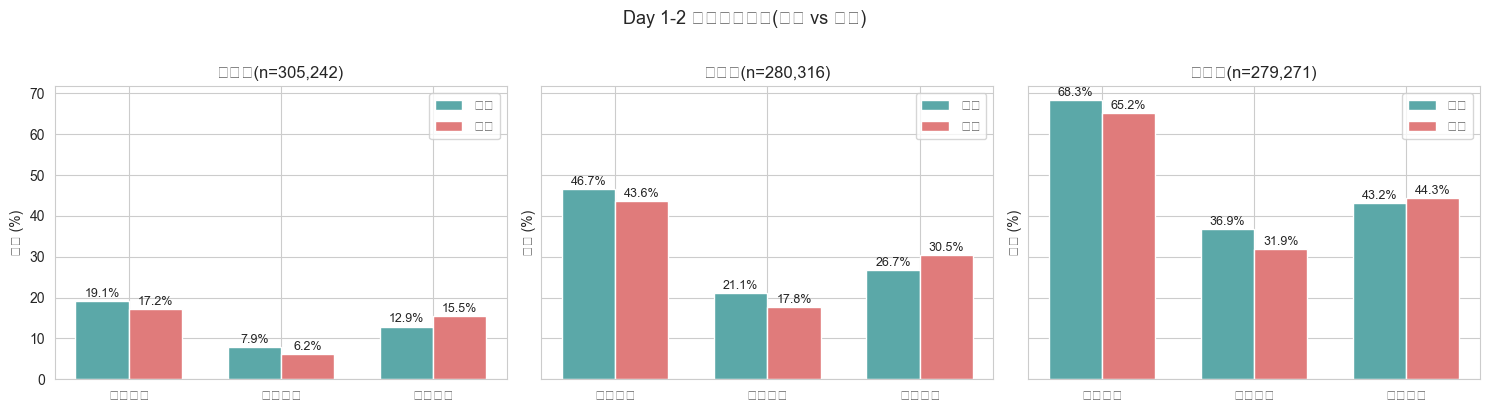

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, tier_name in zip(axes, ['低活跃', '中活跃', '高活跃']):
    df_tier = cohort_df[cohort_df['tier'] == tier_name]
    dead  = df_tier[df_tier['is_dead']]
    alive = df_tier[~df_tier['is_dead']]

    metrics = ['d12_has_cart', 'd12_has_fav', 'd12_has_buy']
    labels  = ['有过加购', '有过收藏', '有过购买']
    dead_pct  = [dead[m].mean()  * 100 for m in metrics]
    alive_pct = [alive[m].mean() * 100 for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35
    ax.bar(x - width/2, alive_pct, width, label='活跃', color='#5BA8A8')
    ax.bar(x + width/2, dead_pct,  width, label='假死', color='#E07B7B')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('占比 (%)')
    ax.set_title(f'{tier_name}(n={len(df_tier):,})')
    ax.legend()
    for i, (a, d) in enumerate(zip(alive_pct, dead_pct)):
        ax.text(i - width/2, a + 1, f'{a:.1f}%', ha='center', fontsize=9)
        ax.text(i + width/2, d + 1, f'{d:.1f}%', ha='center', fontsize=9)

plt.suptitle('Day 1-2 转化深度对比(假死 vs 活跃)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## 5. 时段活跃分布对比

看假死用户和活跃用户在 Day 1-2 的活跃**时段分布**(24 小时)有没有差异。

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 23567 (\N{CJK UNIFIED IDEOGRAPH-5C0F}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\33238\AppData\Local\Temp\ipykernel_109908\3676040550.py:36: UserWarning: Glyph 20026 (\N{CJK UNIFIED IDEOGRAPH-

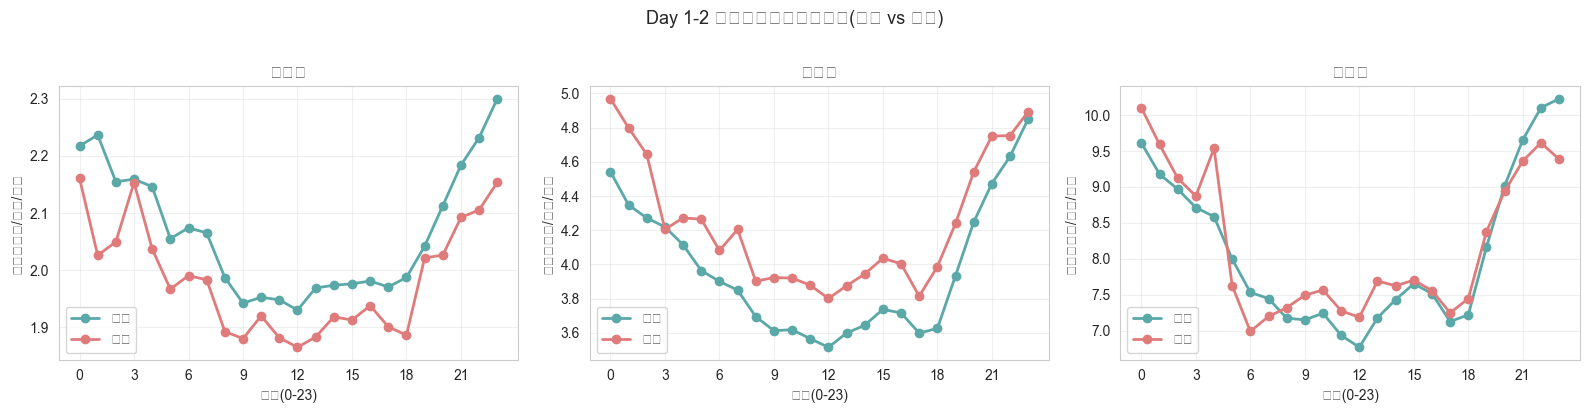

In [6]:
# 每个用户 × 小时的行为数(直接从原始数据 group by)
hourly = con.sql("""
WITH cohort AS (
    SELECT DISTINCT user_id FROM ub
    WHERE event_date IN (DATE '2017-11-25', DATE '2017-11-26')
)
SELECT u.user_id, u.hour, COUNT(*) AS actions
FROM ub u
INNER JOIN cohort c ON u.user_id = c.user_id
WHERE u.event_date IN (DATE '2017-11-25', DATE '2017-11-26')
GROUP BY u.user_id, u.hour
""").df()

# join 假死标签
hourly = hourly.merge(cohort_df[['user_id', 'tier', 'is_dead']], on='user_id')

# 各 tier 下假死 vs 活跃,各小时**平均**行为数
hourly_avg = hourly.groupby(['tier', 'is_dead', 'hour'], observed=True)['actions'].mean().reset_index()

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=False)
for ax, tier_name in zip(axes, ['低活跃', '中活跃', '高活跃']):
    for is_dead_flag, color, label in [(False, '#5BA8A8', '活跃'), (True, '#E07B7B', '假死')]:
        sub = hourly_avg[(hourly_avg['tier'] == tier_name) & (hourly_avg['is_dead'] == is_dead_flag)]
        # 把 0-23 小时补齐(没行为的小时填 0)
        full = sub.set_index('hour').reindex(range(24), fill_value=0)['actions']
        ax.plot(full.index, full.values, marker='o', color=color, label=label, linewidth=2)
    ax.set_title(f'{tier_name}')
    ax.set_xlabel('小时(0-23)')
    ax.set_ylabel('平均行为数/用户/小时')
    ax.set_xticks(range(0, 24, 3))
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle('Day 1-2 各小时平均行为数对比(假死 vs 活跃)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**怎么读这三张图**:
- 横轴:小时(0-23)
- 纵轴:**每用户每小时**的平均行为数
- 看是否有时段差异:比如假死用户是不是更集中在某个时段(说明他们是"碎片化用户")
- 如果两条线**几乎重合**,说明时段不是辨别假死的有效信号
- 如果有明显错峰,可作为"召回 push 时机"的依据

---

## 6. 输出 ADS 层假死用户名单

把三层假死用户标记落盘,后续切口 D 建模时可作为输入特征。

In [7]:
# 输出 ADS 层文件
ADS_PATH = Path('../data/processed/ADS').resolve()
ADS_PATH.mkdir(parents=True, exist_ok=True)

# 完整画像 + 标签
dead_users_export = cohort_df[cohort_df['is_dead']].copy()
print(f'假死用户总数:{len(dead_users_export):,}')

out_path = ADS_PATH / 'dead_users_profile.parquet'
dead_users_export.to_parquet(out_path, index=False)
print(f'已写入: {out_path}')
print(f'体积: {out_path.stat().st_size / 1024:.1f} KB')

# 顺便保留所有 cohort 用户的标签(给切口 D 用)
cohort_label_path = ADS_PATH / 'cohort_full_labels.parquet'
cohort_df.to_parquet(cohort_label_path, index=False)
print(f'已写入(全 cohort 含标签): {cohort_label_path}')

假死用户总数:115,557
已写入: D:\IndividualProject\留存分析项目\data\processed\ADS\dead_users_profile.parquet
体积: 1557.2 KB
已写入(全 cohort 含标签): D:\IndividualProject\留存分析项目\data\processed\ADS\cohort_full_labels.parquet


---

## 7. 你的观察记录(等填)

> _跑完上面所有 cell 后,在这里写你对三个 tier 假死画像的观察_

### 7.1 三层假死率
> - 低活跃假死率:_____ %
> - 中活跃假死率:_____ %
> - 高活跃假死率:_____ %

### 7.2 每层最有辨识度的 Day 1-2 特征
> 看 Part 3 的对比表,标记每层"显著且 diff 大"的特征:
> - 低活跃:___
> - 中活跃:___
> - 高活跃:___

### 7.3 时段图有没有发现可利用的差异?
> - 有/没有,具体观察:___

### 7.4 初步召回策略想法
> - 低活跃假死:在 Day _ 推送 ___ 类型内容,因为 ___
> - 中活跃假死:_______
> - 高活跃假死:_______

跑完之后告诉 AI 关键结果,我们进入 06 notebook:**活跃度演变与跨层迁移分析**。
